### ДЗ №1

In [162]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
from IPython.display import display

In [163]:
df = pd.read_csv("heart.csv")
df.head() # верхние строки

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [164]:
# проверка пропусков (NaN)
missing = df.isna().sum()
missing[missing > 0]

Series([], dtype: int64)

In [165]:
# деление признаков на "числовые" и "категориальные"
categorical = ["sex", "cp", "fbs", "restecg", "exang", "slope", "ca", "thal", "target"]
numeric = [c for c in df.columns if c not in categorical]

print("Числовые:", numeric)
print("Категориальные:", categorical)

Числовые: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Категориальные: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'target']


In [166]:
# медиана и мода
stats_num = df[numeric].describe().T
stats_num["median"] = df[numeric].median()
stats_num["mode"] = df[numeric].mode().iloc[0]
stats_num

,count,mean,std,min,25%,50%,75%,max,median,mode
age,303.0,54.366337,9.082101,29.0,47.5,55.0,61.0,77.0,55.0,58.0
trestbps,303.0,131.623762,17.538143,94.0,120.0,130.0,140.0,200.0,130.0,120.0
chol,303.0,246.264026,51.830751,126.0,211.0,240.0,274.5,564.0,240.0,197.0
thalach,303.0,149.646865,22.905161,71.0,133.5,153.0,166.0,202.0,153.0,162.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2,0.8,0.0


In [167]:
# категориальные признаки
cat_summary = {}
for col in categorical:
    cat_summary[col] = {
        "unique_values": sorted(df[col].unique().tolist()),
        "counts": df[col].value_counts().to_dict()
    }
cat_summary

{'sex': {'unique_values': [0, 1], 'counts': {1: 207, 0: 96}},
 'cp': {'unique_values': [0, 1, 2, 3],
  'counts': {0: 143, 2: 87, 1: 50, 3: 23}},
 'fbs': {'unique_values': [0, 1], 'counts': {0: 258, 1: 45}},
 'restecg': {'unique_values': [0, 1, 2], 'counts': {1: 152, 0: 147, 2: 4}},
 'exang': {'unique_values': [0, 1], 'counts': {0: 204, 1: 99}},
 'slope': {'unique_values': [0, 1, 2], 'counts': {2: 142, 1: 140, 0: 21}},
 'ca': {'unique_values': [0, 1, 2, 3, 4],
  'counts': {0: 175, 1: 65, 2: 38, 3: 20, 4: 5}},
 'thal': {'unique_values': [0, 1, 2, 3],
  'counts': {2: 166, 3: 117, 1: 18, 0: 2}},
 'target': {'unique_values': [0, 1], 'counts': {1: 165, 0: 138}}}

In [168]:
def freq_table(col):
    counts = df[col].value_counts().sort_index()
    perc = (counts / len(df) * 100).round(2)
    return pd.DataFrame({"count": counts, "percent": perc})

freq_table("sex")

,count,percent
sex,,
0,96,31.68
1,207,68.32


In [169]:
def freq_table(s):
    counts = s.value_counts(dropna=False).sort_index()
    perc = (counts / len(s) * 100).round(2)
    return pd.DataFrame({"count": counts, "percent": perc})

cat_tables = {col: freq_table(df[col]) for col in categorical}

big = pd.concat(cat_tables, names=["feature", "value"]).reset_index()
big.columns = ["feature", "value", "count", "percent"]

display(big)


,feature,value,count,percent
0,sex,0,96,31.68
1,sex,1,207,68.32
2,cp,0,143,47.19
3,cp,1,50,16.50
4,cp,2,87,28.71
5,cp,3,23,7.59
6,fbs,0,258,85.15
7,fbs,1,45,14.85
8,restecg,0,147,48.51
9,restecg,1,152,50.17


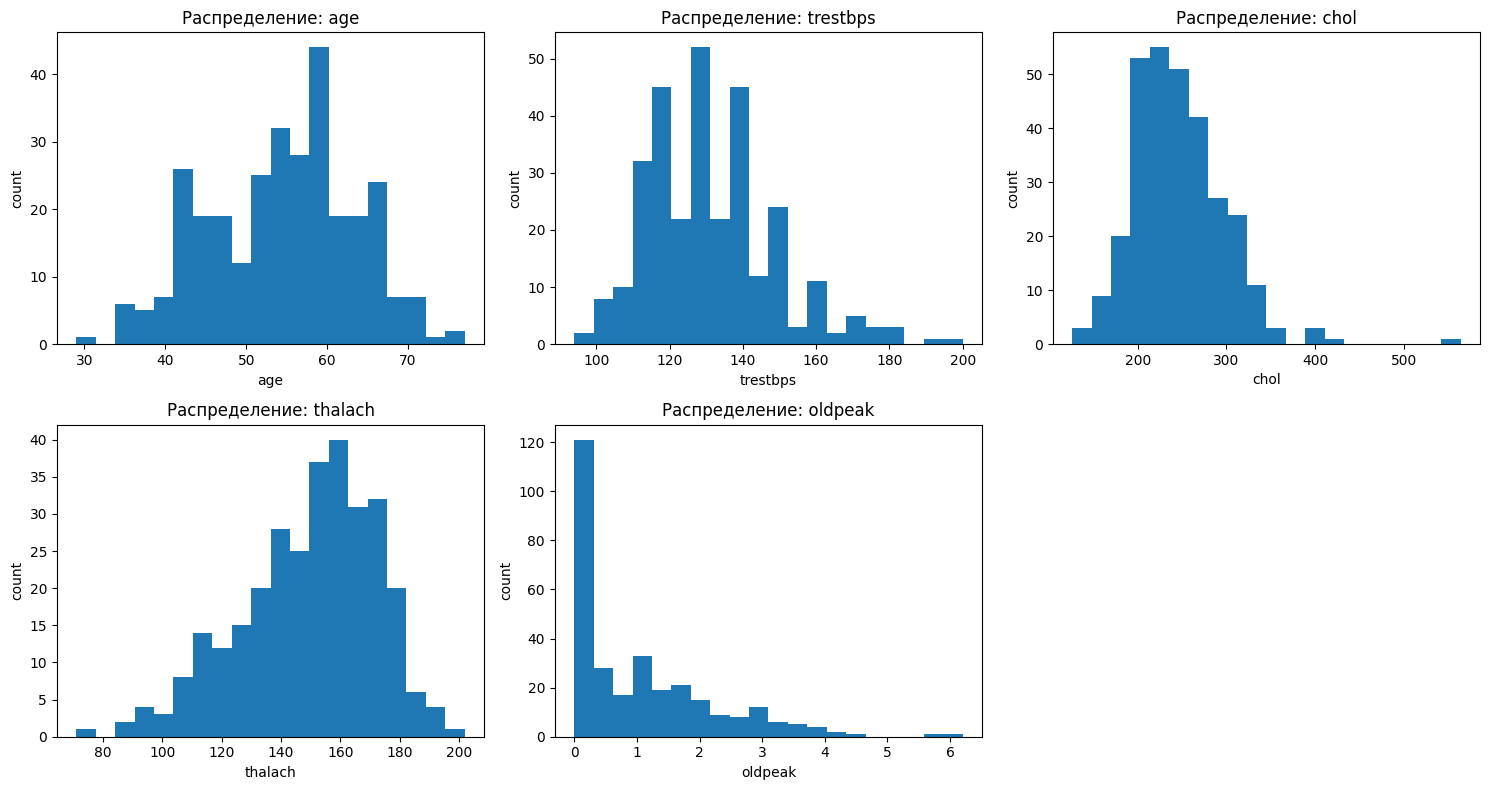

In [170]:
ncols = 3

nrows = math.ceil(len(numeric) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric):
    axes[i].hist(df[col], bins=20)
    axes[i].set_title(f"Распределение: {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

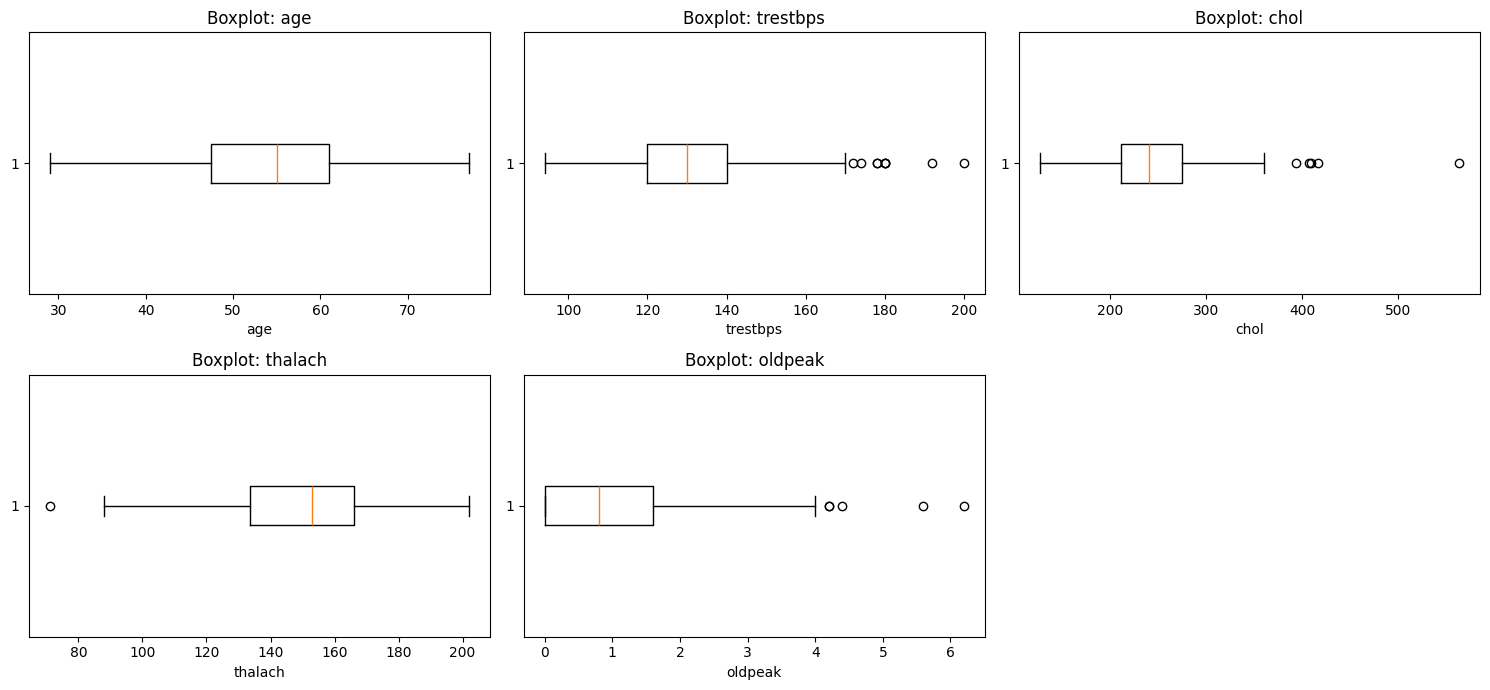

In [171]:
ncols = 3

nrows = math.ceil(len(numeric) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.5*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric):
    axes[i].boxplot(df[col].dropna(), vert=False)
    axes[i].set_title(f"Boxplot: {col}")
    axes[i].set_xlabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [172]:
corr = df[numeric + ["target"]].corr(numeric_only=True)
corr

,age,trestbps,chol,thalach,oldpeak,target
age,1.000000,0.279351,0.213678,-0.398522,0.210013,-0.225439
trestbps,0.279351,1.000000,0.123174,-0.046698,0.193216,-0.144931
chol,0.213678,0.123174,1.000000,-0.009940,0.053952,-0.085239
thalach,-0.398522,-0.046698,-0.009940,1.000000,-0.344187,0.421741
oldpeak,0.210013,0.193216,0.053952,-0.344187,1.000000,-0.430696
target,-0.225439,-0.144931,-0.085239,0.421741,-0.430696,1.000000


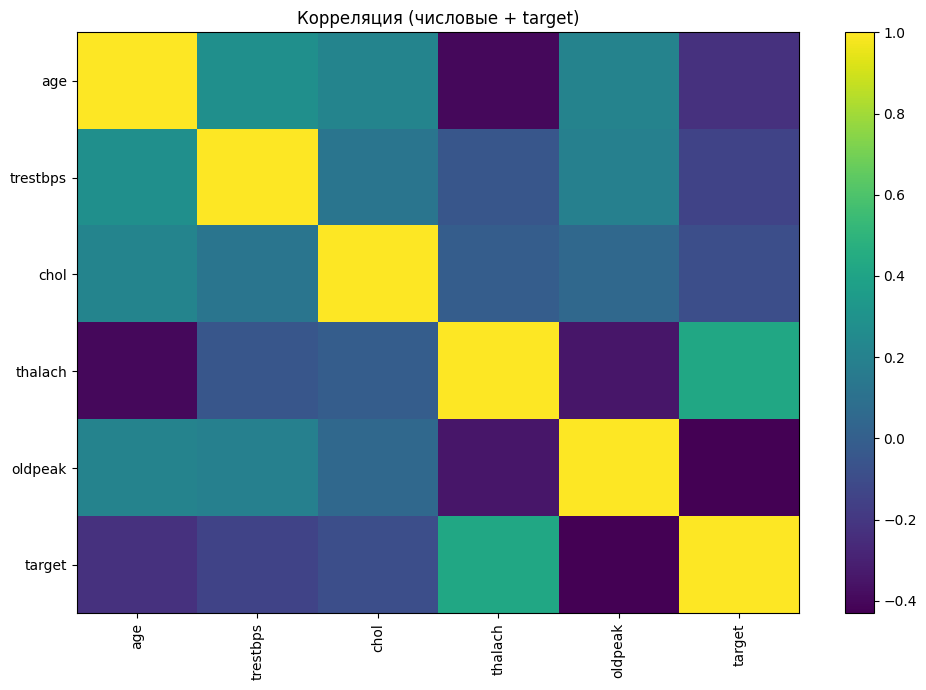

In [173]:
# Тепловая карта корреляций
plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.index)), corr.index)
plt.title("Корреляция (числовые + target)")
plt.tight_layout()
plt.show()

Сравнение по target (есть болезнь / нет болезни) target: 1 — болезнь сердца есть, 0 — болезни нет.

In [174]:
# ср значения по target
df.groupby("target")[numeric].mean().T

target,0,1
age,56.601449,52.496970
trestbps,134.398551,129.303030
chol,251.086957,242.230303
thalach,139.101449,158.466667
oldpeak,1.585507,0.583030


In [175]:
# медианы по target
df.groupby("target")[numeric].median().T

target,0,1
age,58.0,52.0
trestbps,130.0,130.0
chol,249.0,234.0
thalach,142.0,161.0
oldpeak,1.4,0.2


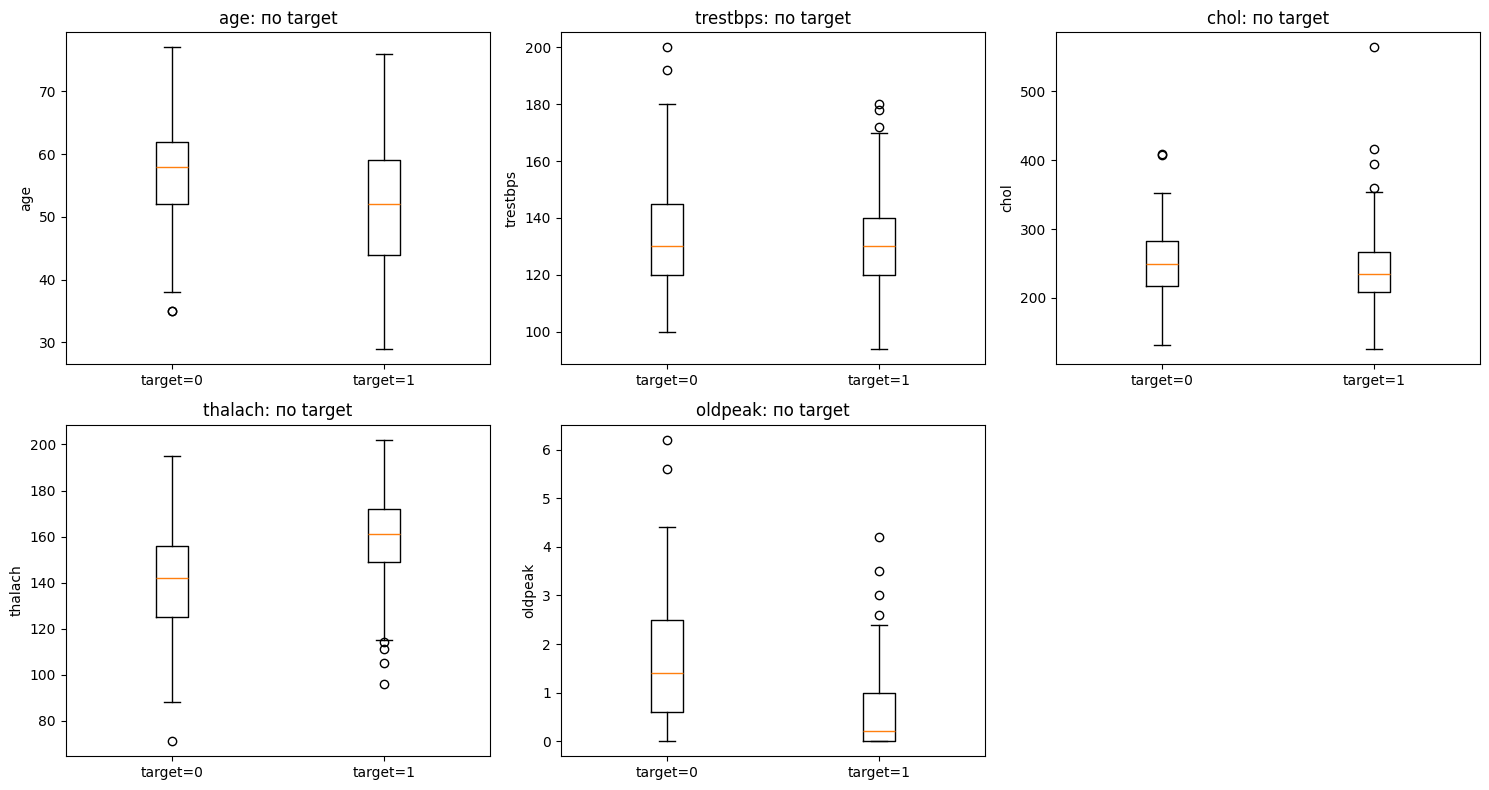

In [176]:
ncols = 3
nrows = math.ceil(len(numeric) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(numeric):
    data0 = df.loc[df["target"] == 0, col].dropna()
    data1 = df.loc[df["target"] == 1, col].dropna()

    axes[i].boxplot([data0, data1], tick_labels=["target=0", "target=1"])  # без warning
    axes[i].set_title(f"{col}: по target")
    axes[i].set_ylabel(col)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Данные загрузились нормально, таблица не пустая, пропусков в данных нет.

Классы target=0 и target=1 представлены примерно одинаково, сильного перекоса нет.

По некоторым признакам группы target=0 и target=1 заметно отличаются (на графиках и в средних значениях это видно).

У людей с target=1 чаще выше максимальный пульс (thalach), а значение oldpeak обычно меньше.

Признак exang (стенокардия при нагрузке) чаще встречается у target=0, чем у target=1.

Тип боли в груди (cp) распределён по-разному в двух группах, значит этот признак может быть важным.

В целом можно сказать, что некоторые признаки действительно связаны с target, поэтому по ним можно пытаться отличать группы.